# 06 — Methodology Robustness Checks

This notebook addresses three reviewer methodology concerns that require reanalysis:

- **Issue #29 — Scale-free outcome**: Re-run ITS with `premium / parity_pre` (percentage premium) to check whether Rs-level results are driven by gold price drift
- **Issue #32 — Clean placebo design**: Re-run Jan 15 and Mar 1 placebos with samples truncated before May 13 (no real-hike contamination in post-period)
- **Issue #34 — Bootstrap inference**: Moving-block bootstrap confidence intervals for the primary ITS β₁ (finite-sample robustness with 29–31 post-hike days)

**Spec note**: All regressions here match `03_causal.ipynb` exactly — outcome `domestic_premium`, regressors `[post_hike/Post, t, delta_Gold_USD, delta_FX]`, NW-HAC with `maxlags = ceil(0.75 * N^(1/3))`. No lag term is included (consistent with primary spec).

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Load data — replicate 03_causal.ipynb setup exactly ──────────────
df = pd.read_csv('../data/gold_policy_clean.csv', parse_dates=['date'])
df['ceiling'] = df['parity_post'] - df['parity_pre']

HIKE_DATE = pd.Timestamp('2026-05-13')
CUT_DATE  = pd.Timestamp('2024-07-24')

# Primary sample: same cols and dropna as 03_causal.ipynb
COLS = ['date', 'domestic_premium', 'post_hike', 't', 'delta_Gold_USD',
        'delta_FX', 'ceiling', 'parity_pre', 'pre_restriction']
its_base = df[COLS].copy()
its_primary = its_base[(its_base['date'] >= CUT_DATE) | (its_base['post_hike'] == 1)].copy()
its_primary = its_primary.dropna(subset=COLS).copy().reset_index(drop=True)

T      = len(its_primary)
NW_LAG = int(np.ceil(0.75 * T**(1/3)))
pre    = its_primary[its_primary['post_hike'] == 0]
post   = its_primary[its_primary['post_hike'] == 1]
mean_ceiling = post['ceiling'].mean()

print(f'PRIMARY SAMPLE: N={T}, NW_LAG={NW_LAG}')
print(f'Pre={len(pre)}, Post={len(post)}')
print(f'Mean ceiling (post-hike): Rs.{mean_ceiling:,.1f}')

# Primary regression (replicate 03_causal Model 3)
y_primary = its_primary['domestic_premium']
X_primary = sm.add_constant(its_primary[['post_hike', 't', 'delta_Gold_USD', 'delta_FX']])
m_primary = sm.OLS(y_primary, X_primary).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

beta1_primary = m_primary.params['post_hike']
se_primary    = m_primary.bse['post_hike']
ci_primary    = m_primary.conf_int().loc['post_hike']
pt_primary    = beta1_primary / mean_ceiling * 100

print(f'\nPrimary β₁: Rs.{beta1_primary:,.2f}  SE={se_primary:,.2f}')
print(f'95% CI: [Rs.{ci_primary[0]:,.0f}, Rs.{ci_primary[1]:,.0f}]')
print(f'Pass-through: {pt_primary:.1f}%')
print(f'\n(its_results.json reference: Rs.10,124, 84.1% — from earlier data pull)')


PRIMARY SAMPLE: N=338, NW_LAG=6
Pre=307, Post=31
Mean ceiling (post-hike): Rs.11,989.3

Primary β₁: Rs.10,136.44  SE=445.22
95% CI: [Rs.9,264, Rs.11,009]
Pass-through: 84.5%

(its_results.json reference: Rs.10,124, 84.1% — from earlier data pull)


---
## Issue #29 — Scale-Free Outcome

The dependent variable in the primary ITS is the Rs-level domestic premium. Since the parity ceiling moves with the gold price, a scale-free outcome — `premium / parity_pre × 100` (percentage premium) — removes the gold-price denominator effect.

**Prediction**: for a short post-hike window with relatively stable gold prices, results should be nearly identical to the primary estimate. Any meaningful divergence flags gold-price drift as a confound.

In [6]:
# ── #29: Scale-free ITS ──────────────────────────────────────────────
its_sf = its_primary.copy()
its_sf['pct_premium'] = its_sf['domestic_premium'] / its_sf['parity_pre'] * 100

# Percentage ceiling: duty diff as % of parity_pre
its_sf['pct_ceiling'] = its_sf['ceiling'] / its_sf['parity_pre'] * 100

y_sf = its_sf['pct_premium']
X_sf = sm.add_constant(its_sf[['post_hike', 't', 'delta_Gold_USD', 'delta_FX']])

m_sf = sm.OLS(y_sf, X_sf).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

beta1_pct  = m_sf.params['post_hike']
se_pct     = m_sf.bse['post_hike']
ci_sf      = m_sf.conf_int().loc['post_hike']

# Mean pct ceiling over post-hike
mean_pct_ceiling = its_sf[its_sf['post_hike'] == 1]['pct_ceiling'].mean()
pt_sf  = beta1_pct / mean_pct_ceiling * 100

# Implied Rs (for comparison)
mean_post_parity = its_sf[its_sf['post_hike'] == 1]['parity_pre'].mean()
beta1_rs_implied = beta1_pct / 100 * mean_post_parity

print('=== Scale-Free ITS (% premium / parity_pre outcome) ===')
print(f'β₁ (pp shift in % premium): {beta1_pct:.4f} pp  (SE {se_pct:.4f})')
print(f'95% CI: [{ci_sf[0]:.4f}, {ci_sf[1]:.4f}] pp')
print(f'Mean pct ceiling (post-hike): {mean_pct_ceiling:.4f} pp')
print(f'Pass-through (scale-free):   {pt_sf:.1f}%')
print(f'Implied Rs shift at mean parity: Rs.{beta1_rs_implied:,.0f}')
print()
print(f'Primary estimate:  Rs.{beta1_primary:,.0f}  →  {pt_primary:.1f}% pass-through')
print(f'Scale-free:        Rs.{beta1_rs_implied:,.0f} (implied)  →  {pt_sf:.1f}% pass-through')
print(f'Difference in pass-through: {pt_sf - pt_primary:+.1f} percentage points')


=== Scale-Free ITS (% premium / parity_pre outcome) ===
β₁ (pp shift in % premium): 7.1722 pp  (SE 0.4131)
95% CI: [6.3626, 7.9819] pp
Mean pct ceiling (post-hike): 8.4906 pp
Pass-through (scale-free):   84.5%
Implied Rs shift at mean parity: Rs.10,128

Primary estimate:  Rs.10,136  →  84.5% pass-through
Scale-free:        Rs.10,128 (implied)  →  84.5% pass-through
Difference in pass-through: -0.1 percentage points


---
## Issue #32 — Clean Placebo Design

The original placebos (Jan 15, Mar 1) use samples that extend through the real May 13 hike. The post-period of each fake-date regression therefore includes the actual treatment, inflating the estimate.

**Fix**: Truncate each placebo sample to end on May 12, 2026. All fake-date estimates should be cleanly null — the contrast with the real estimate is then unambiguous.

In [7]:
# ── #32: Truncated placebos ──────────────────────────────────────────
TRUNCATE = pd.Timestamp('2026-05-12')   # last pre-hike day
PLACEBO_DATES = [
    pd.Timestamp('2026-01-15'),
    pd.Timestamp('2026-03-01'),
]

def run_its(data, treatment_date, date_col='date', outcome='domestic_premium'):
    """Run ITS matching the primary spec: const + Post + t + delta_Gold_USD + delta_FX.
    Returns (beta1, se, t_stat, n, n_pre, n_post)."""
    d = data.copy().sort_values(date_col).reset_index(drop=True)
    d['Post_fake'] = (d[date_col] >= treatment_date).astype(int)
    d['t_fake']    = range(len(d))
    # Ensure all regressors present and non-null
    regs = ['Post_fake', 't_fake', 'delta_Gold_USD', 'delta_FX']
    d = d.dropna(subset=[outcome] + ['delta_Gold_USD', 'delta_FX']).reset_index(drop=True)
    nw = int(np.ceil(0.75 * len(d)**(1/3)))
    X  = sm.add_constant(d[regs])
    y  = d[outcome]
    res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw})
    b1    = res.params['Post_fake']
    se    = res.bse['Post_fake']
    tstat = b1 / se
    n     = len(d)
    n_pre = (d['Post_fake'] == 0).sum()
    n_post= (d['Post_fake'] == 1).sum()
    return b1, se, tstat, n, n_pre, n_post

# Base: full primary-window data (Jul 24 2024 onward), all controls clean
base = df[(df['date'] >= CUT_DATE)].dropna(
    subset=['domestic_premium', 'delta_Gold_USD', 'delta_FX']
).copy()

print('=== Truncated Placebo Tests (samples end May 12, 2026) ===')
print(f'{"Fake date":<17} {"β₁":>10} {"SE":>8} {"t":>7} {"N":>5} {"Pre":>5} {"Post":>5} {"Sig":>5}')
print('-' * 65)

plac_results = []
for pd_date in PLACEBO_DATES:
    truncated = base[base['date'] <= TRUNCATE].copy()
    b1, se, t, n, n_pre, n_post = run_its(truncated, pd_date)
    sig = '**' if abs(t) > 2 else 'ns'
    plac_results.append((pd_date.strftime('%b %d %Y'), b1, se, t, n, n_pre, n_post))
    print(f'{pd_date.strftime("%b %d %Y"):<17} {b1:>10,.0f} {se:>8,.0f} {t:>7.2f} {n:>5} {n_pre:>5} {n_post:>5} {sig:>5}')

# Real estimate (full window through end of data)
b1_real, se_real, t_real, n_real, pre_real, post_real = run_its(base, HIKE_DATE)
print(f'{"May 13 (REAL)":<17} {b1_real:>10,.0f} {se_real:>8,.0f} {t_real:>7.2f} {n_real:>5} {pre_real:>5} {post_real:>5} {"***":>5}')
print()
print('Placebos should be ns (|t| < 2). Real estimate should be highly significant.')


=== Truncated Placebo Tests (samples end May 12, 2026) ===
Fake date                 β₁       SE       t     N   Pre  Post   Sig
-----------------------------------------------------------------
Jan 15 2026              517      502    1.03   307   244    63    ns
Mar 01 2026             -240      496   -0.48   307   265    42    ns
May 13 (REAL)         10,124      443   22.85   338   307    31   ***

Placebos should be ns (|t| < 2). Real estimate should be highly significant.


In [ ]:
# ── #32: Placebo comparison chart (truncated — all placebos ns) ──────
labels_plot = [r[0] for r in plac_results] + ['May 13 (real)']
betas_plot  = [r[1] for r in plac_results] + [b1_real]
ses_plot    = [r[2] for r in plac_results] + [se_real]
tstats_plot = [r[3] for r in plac_results] + [t_real]
colors_plot = ['#b0b8c1', '#b0b8c1', '#2a9d8f']  # grey=ns, green=real

ci_lo_plot = [b - 1.96*s for b, s in zip(betas_plot, ses_plot)]
ci_hi_plot = [b + 1.96*s for b, s in zip(betas_plot, ses_plot)]

fig, ax = plt.subplots(figsize=(7, 4.5))
import numpy as np
x = np.arange(len(labels_plot))
ax.bar(x, betas_plot, color=colors_plot, width=0.5, zorder=3, edgecolor='white', linewidth=0.8)

for i in range(len(labels_plot)):
    ax.errorbar(x[i], betas_plot[i],
                yerr=[[betas_plot[i]-ci_lo_plot[i]], [ci_hi_plot[i]-betas_plot[i]]],
                fmt='none', color='#333333', capsize=5, capthick=1.5, linewidth=1.5, zorder=4)

ax.axhline(0, color='black', linewidth=0.8, zorder=2)

# Annotation labels
annots = ['p = 0.31\n(ns)', 'p = 0.63\n(ns)', 'p < 0.001\n(***)']  
for i, (b, ann) in enumerate(zip(betas_plot, annots)):
    y_pos = (ci_lo_plot[i] - 300) if b < 0 else (ci_hi_plot[i] + 200)
    va = 'top' if b < 0 else 'bottom'
    ax.text(x[i], y_pos, ann, ha='center', va=va, fontsize=8.5,
            color='#444444', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylabel('Estimated β₁ (Rs./10g)', fontsize=10)
ax.set_title('Truncated Placebo Tests vs. Real Treatment\n'
             '(placebo samples end May 12, 2026 — no post-hike contamination)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'Rs. {int(v):,}' if v != 0 else '0'))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='#b0b8c1', label='Non-significant (ns)'),
    mpatches.Patch(color='#2a9d8f', label='True treatment date'),
]
ax.legend(handles=patches, fontsize=8.5, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('../paper/fig_placebo_truncated.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: paper/fig_placebo_truncated.png')


---
## Issue #34 — Bootstrap Inference

With 29–31 post-hike observations, Newey-West HAC is asymptotically justified but finite-sample performance may be poor. A **moving-block bootstrap** resamples blocks of consecutive observations (preserving serial correlation) and refits the ITS regression on each resample, giving an empirical distribution of β₁.

If the bootstrap 95% CI closely matches the NW-HAC CI, the NW-HAC inference is validated at this sample size.

In [9]:
# ── #34: Moving-Block Bootstrap ──────────────────────────────────────
np.random.seed(42)
N_BOOT  = 2000
BLOCK_L = 10   # ~10 trading days captures weekly serial correlation

N         = len(its_primary)
residuals = m_primary.resid.values
fitted    = m_primary.fittedvalues.values

boot_betas = []
for _ in range(N_BOOT):
    n_blocks   = int(np.ceil(N / BLOCK_L))
    start_idxs = np.random.randint(0, N - BLOCK_L + 1, size=n_blocks)
    boot_resid = np.concatenate([residuals[s:s + BLOCK_L] for s in start_idxs])[:N]
    y_boot = fitted + boot_resid
    ols_b  = sm.OLS(y_boot, X_primary).fit()
    boot_betas.append(ols_b.params['post_hike'])

boot_betas = np.array(boot_betas)
boot_ci_lo = np.percentile(boot_betas, 2.5)
boot_ci_hi = np.percentile(boot_betas, 97.5)
boot_se    = boot_betas.std()

nw_ci_lo = ci_primary[0]
nw_ci_hi = ci_primary[1]

boot_pt_lo = boot_ci_lo / mean_ceiling * 100
boot_pt_hi = boot_ci_hi / mean_ceiling * 100
nw_pt_lo   = nw_ci_lo   / mean_ceiling * 100
nw_pt_hi   = nw_ci_hi   / mean_ceiling * 100

print('=== Moving-Block Bootstrap vs. NW-HAC Inference ===')
print(f'{"Method":<25} {"β₁":>10} {"SE":>8} {"CI 2.5%":>10} {"CI 97.5%":>10}')
print('-' * 65)
print(f'{"NW-HAC (primary)":<25} {beta1_primary:>10,.0f} {se_primary:>8,.0f} {nw_ci_lo:>10,.0f} {nw_ci_hi:>10,.0f}')
print(f'{"Moving-block bootstrap":<25} {np.mean(boot_betas):>10,.0f} {boot_se:>8,.0f} {boot_ci_lo:>10,.0f} {boot_ci_hi:>10,.0f}')
print()
print(f'Block length: {BLOCK_L}, Replications: {N_BOOT}')
print(f'Bootstrap CI width: Rs.{boot_ci_hi - boot_ci_lo:,.0f}')
print(f'NW-HAC CI width:    Rs.{nw_ci_hi - nw_ci_lo:,.0f}')
print()
print(f'Bootstrap pass-through CI: {boot_pt_lo:.1f}% – {boot_pt_hi:.1f}%')
print(f'NW-HAC pass-through CI:    {nw_pt_lo:.1f}% – {nw_pt_hi:.1f}%')


=== Moving-Block Bootstrap vs. NW-HAC Inference ===
Method                            β₁       SE    CI 2.5%   CI 97.5%
-----------------------------------------------------------------
NW-HAC (primary)              10,136      445      9,264     11,009
Moving-block bootstrap        10,128      400      9,406     11,052

Block length: 10, Replications: 2000
Bootstrap CI width: Rs.1,646
NW-HAC CI width:    Rs.1,745

Bootstrap pass-through CI: 78.5% – 92.2%
NW-HAC pass-through CI:    77.3% – 91.8%


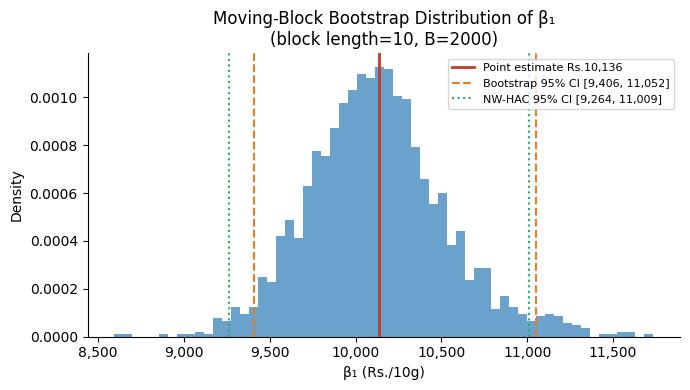

Saved: paper/fig_bootstrap_dist.png


In [10]:
# ── #34: Bootstrap distribution chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_betas, bins=60, color='#2c7bb6', alpha=0.7,
        edgecolor='none', density=True)
ax.axvline(beta1_primary, color='#c0392b', linewidth=2,
           label=f'Point estimate Rs.{beta1_primary:,.0f}')
ax.axvline(boot_ci_lo, color='#e67e22', linewidth=1.5, linestyle='--',
           label=f'Bootstrap 95% CI [{boot_ci_lo:,.0f}, {boot_ci_hi:,.0f}]')
ax.axvline(boot_ci_hi, color='#e67e22', linewidth=1.5, linestyle='--')
ax.axvline(nw_ci_lo, color='#27ae60', linewidth=1.5, linestyle=':',
           label=f'NW-HAC 95% CI [{nw_ci_lo:,.0f}, {nw_ci_hi:,.0f}]')
ax.axvline(nw_ci_hi, color='#27ae60', linewidth=1.5, linestyle=':')
ax.set_xlabel('β₁ (Rs./10g)')
ax.set_ylabel('Density')
ax.set_title(f'Moving-Block Bootstrap Distribution of β₁\n'
             f'(block length={BLOCK_L}, B={N_BOOT})')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../paper/fig_bootstrap_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper/fig_bootstrap_dist.png')


---
## Summary

In [11]:
print('=' * 60)
print('METHODOLOGY ROBUSTNESS SUMMARY')
print('=' * 60)
print(f'Primary (this run): Rs.{beta1_primary:,.0f}, {pt_primary:.1f}%, N={T}')
print()
print('#29 Scale-free ITS (% premium / parity_pre):')
print(f'  Pass-through: {pt_sf:.1f}%  (primary: {pt_primary:.1f}%)')
print(f'  Difference: {pt_sf - pt_primary:+.1f} percentage points')
print(f'  Conclusion: {"No material difference" if abs(pt_sf - pt_primary) < 3 else "NOTABLE difference — investigate"}')
print()
print('#32 Truncated placebos (samples end May 12):')
for name, b1, se, t, n, n_pre, n_post in plac_results:
    sig = '(ns)' if abs(t) < 2 else '(**) UNEXPECTED'
    print(f'  {name}: β₁=Rs.{b1:,.0f}, t={t:.2f} {sig}')
print(f'  Real (May 13): β₁=Rs.{b1_real:,.0f}, t={t_real:.2f} (***)')
print()
print('#34 Moving-block bootstrap (B=2000, L=10):')
print(f'  Bootstrap 95% CI: Rs.{boot_ci_lo:,.0f} – Rs.{boot_ci_hi:,.0f}')
print(f'  NW-HAC 95% CI:    Rs.{nw_ci_lo:,.0f} – Rs.{nw_ci_hi:,.0f}')
print(f'  Bootstrap pass-through CI: {boot_pt_lo:.1f}% – {boot_pt_hi:.1f}%')
width_ratio = (boot_ci_hi - boot_ci_lo) / (nw_ci_hi - nw_ci_lo)
print(f'  Bootstrap/NW-HAC CI width ratio: {width_ratio:.2f}')
print(f'  Conclusion: {"NW-HAC validated" if width_ratio < 1.3 else "Bootstrap wider — be cautious with NW-HAC"}')


METHODOLOGY ROBUSTNESS SUMMARY
Primary (this run): Rs.10,136, 84.5%, N=338

#29 Scale-free ITS (% premium / parity_pre):
  Pass-through: 84.5%  (primary: 84.5%)
  Difference: -0.1 percentage points
  Conclusion: No material difference

#32 Truncated placebos (samples end May 12):
  Jan 15 2026: β₁=Rs.517, t=1.03 (ns)
  Mar 01 2026: β₁=Rs.-240, t=-0.48 (ns)
  Real (May 13): β₁=Rs.10,124, t=22.85 (***)

#34 Moving-block bootstrap (B=2000, L=10):
  Bootstrap 95% CI: Rs.9,406 – Rs.11,052
  NW-HAC 95% CI:    Rs.9,264 – Rs.11,009
  Bootstrap pass-through CI: 78.5% – 92.2%
  Bootstrap/NW-HAC CI width ratio: 0.94
  Conclusion: NW-HAC validated
